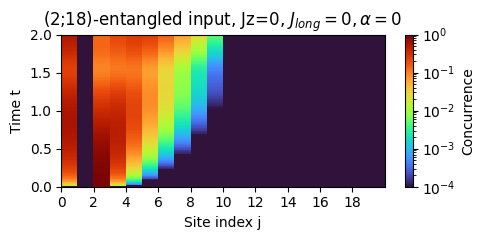

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def row_to_rho(row):
    # row layout: t, p, j, trace, [Re00, Im00, ..., Re33, Im33]
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1]
    C = evals[0] - evals[1] - evals[2] - evals[3]
    return max(0, C)

# --------------------------------------------------
# Load the file
# --------------------------------------------------
configsArray=np.array([2])

for config in configsArray:
    base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
    fname = f"{base}{config}Concurrence.txt"
    # Load numerically, not as strings
    data = np.loadtxt(fname)

    # --------------------------------------------------
    # Build concurrence matrix (time × site)
    # --------------------------------------------------
    p_target = 1
    ns = 20

    uniq_times = np.unique(data[:,0])
    Cmat = np.zeros((len(uniq_times), ns))
    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    for row in data:
        t, p, j = row[0], int(row[1]), int(row[2])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        C = concurrence(rho)
        Cmat[time_to_row[t], j] = C

    # --------------------------------------------------
    # Plot heatmap
    # --------------------------------------------------
    t_min, t_max = uniq_times.min(), uniq_times.max()

    plt.figure(figsize=(5, 2.5))

    im = plt.imshow(
        np.clip(Cmat, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(Cmat + 1e-12)),
        interpolation="nearest",
        extent=[0, ns, t_min, t_max],
        rasterized=True
    )


    plt.xticks([x for x in range(0,19,2)], [x for x in range(0,19,2)])
    plt.colorbar(im, label="Concurrence")
    plt.xlabel("Site index j")
    plt.ylabel("Time t")
    if config == 1:
        plt.title(fr"(2,18)-product input, Jz=0, $J_{{long}}=0, \alpha=0$ ")
    if config == 2:
        plt.title(fr"(2;18)-entangled input, Jz=0, $J_{{long}}=0, \alpha=0$ ")
    if config == 3:
        plt.title(fr"(2,18)-product input, Jz=1, $J_{{long}}=2, \alpha=0.5$ ")
    if config == 4:
        plt.title(fr"(2,18)-entangled input, Jz=1, $J_{{long}}=2, \alpha=0.5$ ")
    plt.tight_layout()

plt.show()


In [32]:
a=np.arange(10)
np.sort(a)[::-1]

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

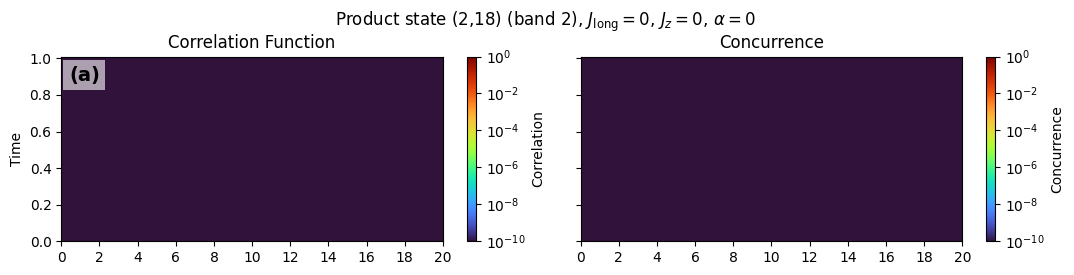

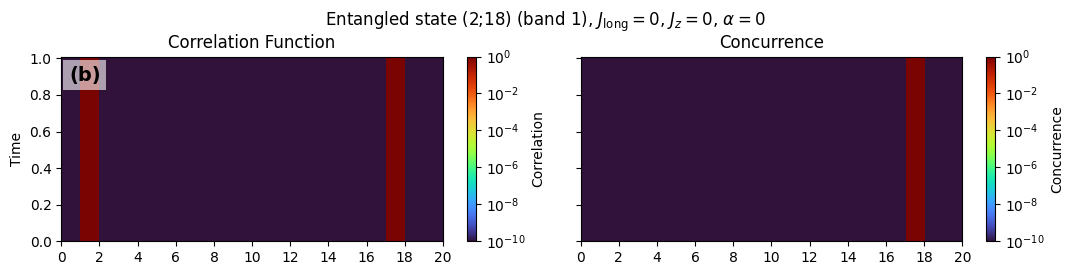

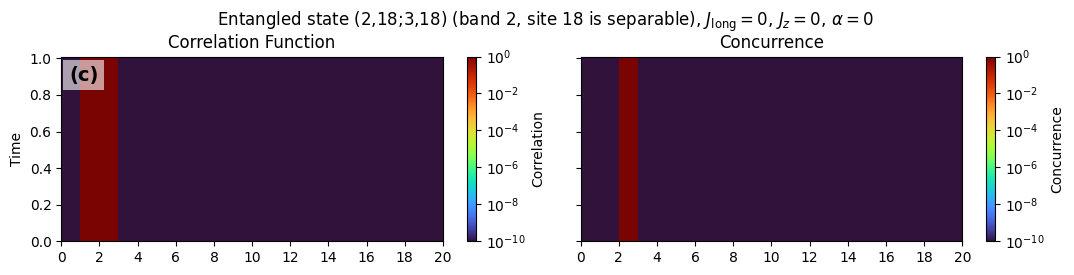

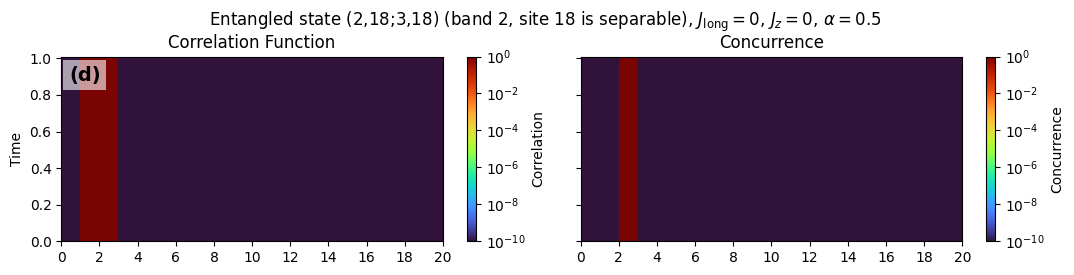

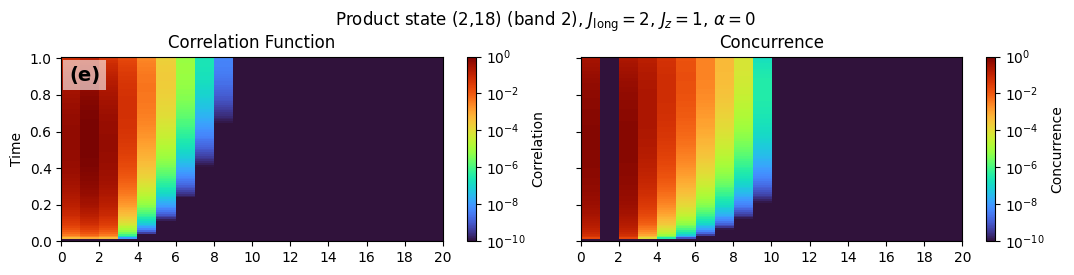

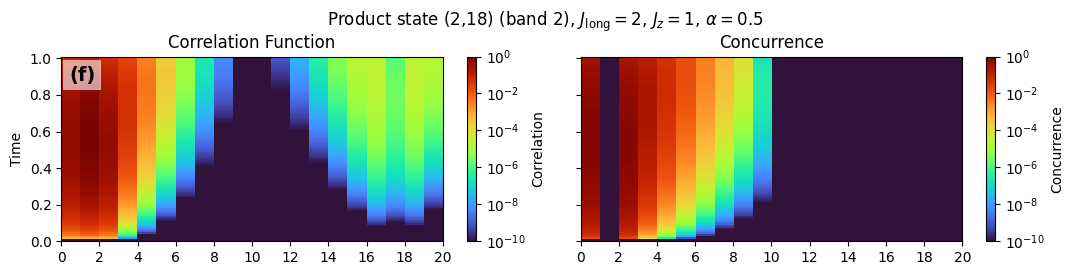

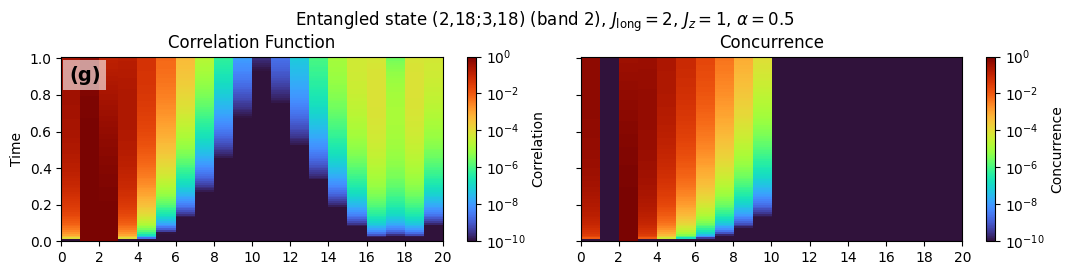

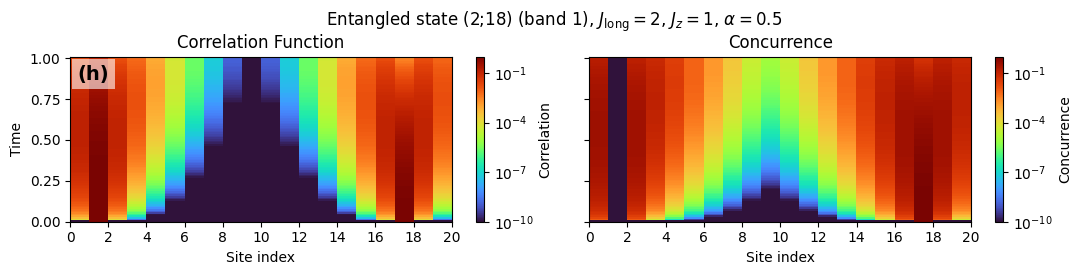

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Convert row → ρ_ij
# --------------------------------------------------
def row_to_rho(row):
    rho_vals = row[4:]
    rho_vals = rho_vals.reshape(4,4,2)
    return rho_vals[:,:,0] + 1j*rho_vals[:,:,1]

# --------------------------------------------------
# Concurrence computation
# --------------------------------------------------
def concurrence(rho):
    sy = np.array([[0, -1j], [1j, 0]])
    S = np.kron(sy, sy)
    rho_tilde = S @ rho.conjugate() @ S
    R = rho @ rho_tilde
    evals = np.real(np.sqrt(np.linalg.eigvals(R)))
    evals = np.sort(evals)[::-1] #sorted in decreasing order
    C = evals[0] - evals[1] - evals[2] - evals[3]
    return max(0, C)#evals[1], evals[2], evals[3]

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
configsArray = [0,6,1,7,2,3,4,5]
ns = 20
p_target = 1

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Projectedband2ConcurrenceTest"
for config in configsArray:
    fnameC = f"{base}{config}Concurrence.txt"
    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    # --------------------------------------------------
    # LOAD FILES
    # --------------------------------------------------
    dataC = np.loadtxt(fnameC)
    dataCorr = np.loadtxt(fnameCorr)

    # correlation file: (N_times × (ns+1))
    times_corr = dataCorr[:,0]
    CorrMat = np.abs(dataCorr[:,1:ns+1])   # shape = (time, sites)

    # --------------------------------------------------
    # Build concurrence matrix
    # --------------------------------------------------
    uniq_times = np.unique(dataC[:,0])
    time_to_row = {t:i for i,t in enumerate(uniq_times)}

    Cmat = np.zeros((len(uniq_times), ns))

    for row in dataC:
        t = row[0]
        j = int(row[2])
        p = int(row[1])
        if p != p_target:
            continue

        rho = row_to_rho(row)
        Cmat[time_to_row[t], j] = concurrence(rho)

    # --------------------------------------------------
    # PLOT SIDE BY SIDE
    # --------------------------------------------------
    t_min, t_max = uniq_times.min(), uniq_times.max()

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(configsArray, start=1)}
    label = label_dict.get(config, "(?)")

    

    fig, ax = plt.subplots(1, 2, figsize=(11, 3), sharey=True)

    # -------- Left: correlation --------
    

    im1 = ax[0].imshow(
        np.clip(CorrMat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),#np.nanmax(CorrMat+1e-12)),
        extent=[0, ns, t_min, t_max]
    )

    

    ax[0].set_title("Correlation Function")
    if config==5:
        ax[0].set_xlabel("Site index")
    ax[0].set_ylabel("Time")
    tick_positions = list(range(0, ns+1, 2))
    tick_labels    = tick_positions

    ax[0].set_xticks(tick_positions)
    ax[0].set_xticklabels(tick_labels)

    ax[1].set_xticks(tick_positions)
    ax[1].set_xticklabels(tick_labels)

    plt.colorbar(im1, ax=ax[0], label="Correlation")

    # -------- Right: concurrence --------
    im2 = ax[1].imshow(
        np.clip(Cmat, 1e-10, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=[0, ns, t_min, t_max]
    )
    ax[1].set_title("Concurrence")
    if config==5:
        ax[1].set_xlabel("Site index")
    plt.colorbar(im2, ax=ax[1], label="Concurrence")
    
    # --------------------------------------------------
    # SUPTITLES FOR EACH CONFIG (0–6)
    # --------------------------------------------------


    if config == 0:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{long}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 6:
        plt.suptitle(
            r"Entangled state (2;18) (band 1), $J_{\text{long}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 1:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2, site 18 is separable), $J_{\text{long}}=0$, $J_z=0$, $\alpha=0$",
            y=0.90
        )
    if config == 7:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2, site 18 is separable), $J_{\text{long}}=0$, $J_z=0$, $\alpha=0.5$",
            y=0.90
        )
    if config == 2:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{long}}=2$, $J_z=1$, $\alpha=0$",
            y=0.90
        )
    if config == 3:
        plt.suptitle(
            r"Product state (2,18) (band 2), $J_{\text{long}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 4:
        plt.suptitle(
            r"Entangled state (2,18;3,18) (band 2), $J_{\text{long}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    if config == 5:
        plt.suptitle(
            r"Entangled state (2;18) (band 1), $J_{\text{long}}=2$, $J_z=1$, $\alpha=0.5$",
            y=0.90
        )
    ax[0].text(
    0.02, 0.95, label,
    transform=ax[0].transAxes,
    fontsize=14, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.tight_layout()
    plt.savefig(f"plt/Concurrence_Corr_Config{config}.svg", dpi=600)
    plt.show()
